In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [18]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Sample - Superstore.csv",encoding="latin1")

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [20]:
df.shape

(9994, 21)

In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [23]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [24]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [27]:
print("Total Sales:", df['Sales'].sum())

Total Sales: 2297200.8603


In [28]:
print("Total Profit:", df['Profit'].sum())

Total Profit: 286397.0217


In [29]:
print("Total Orders:", df['Order ID'].nunique())

Total Orders: 5009


In [30]:
print("Total Customers:", df['Customer ID'].nunique())

Total Customers: 793


In [31]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

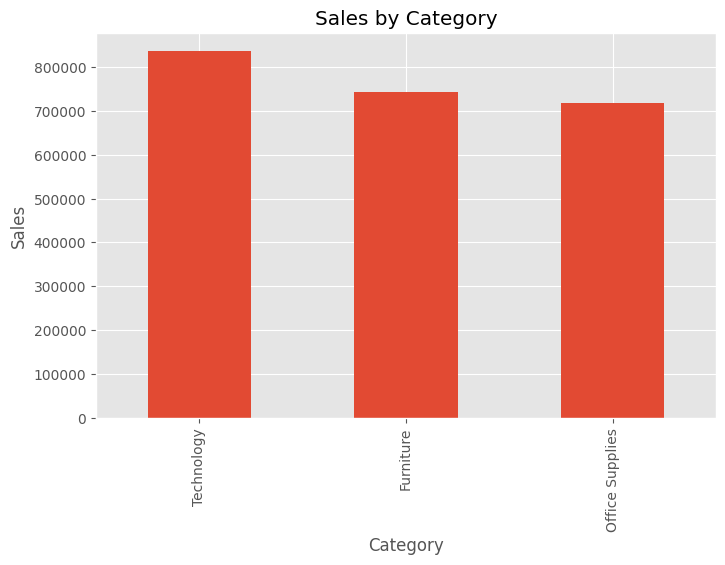

In [32]:
category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

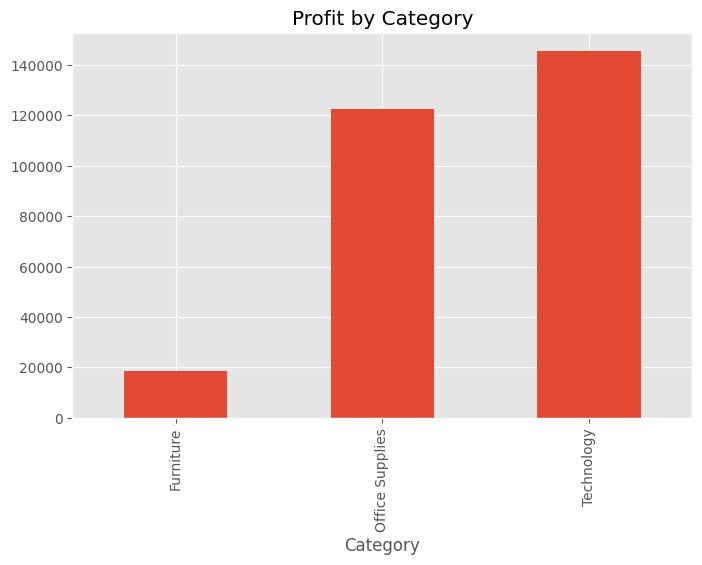

In [33]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar', figsize=(8,5))
plt.title("Profit by Category")
plt.show()

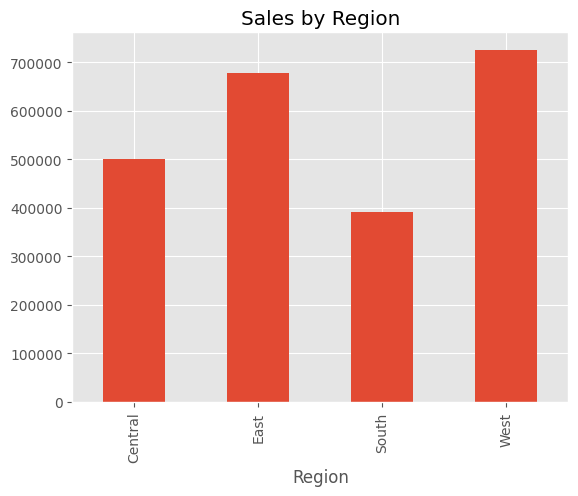

In [34]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

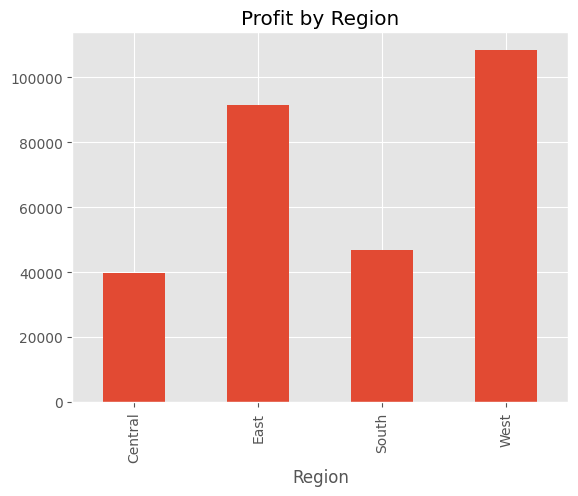

In [35]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

In [38]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.to_period('M')

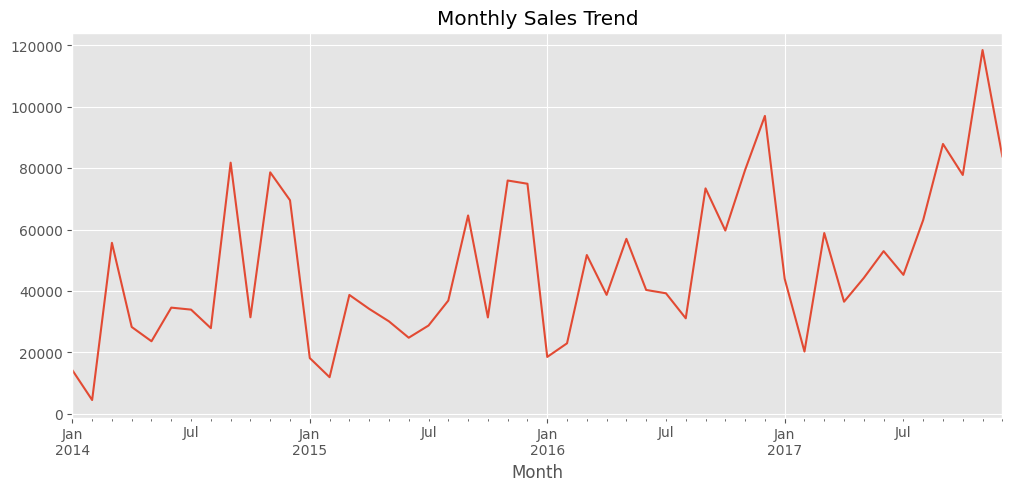

In [39]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.show()

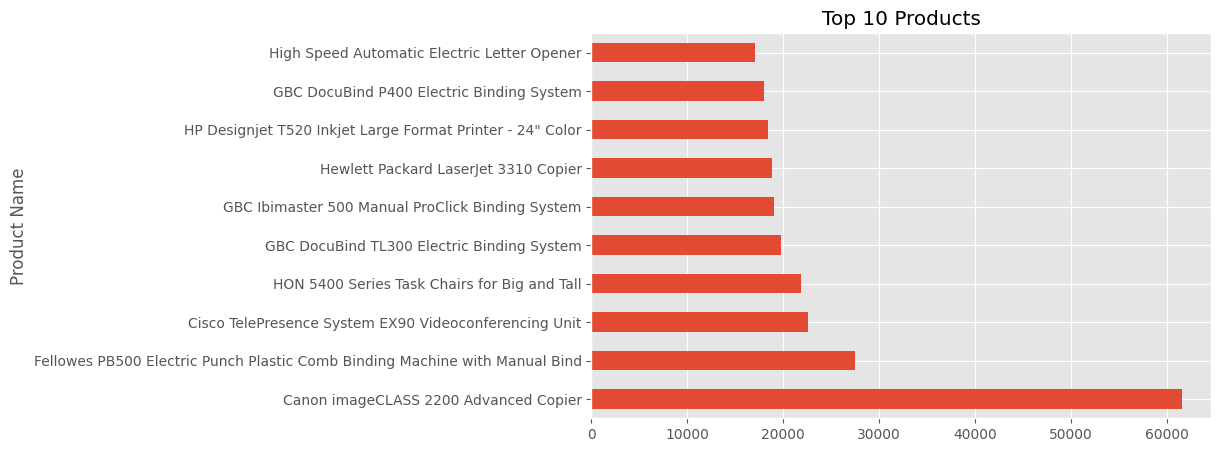

In [41]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Products")
plt.show()

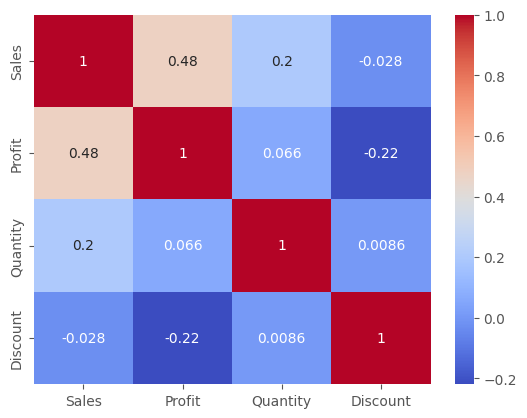

In [42]:
numeric = df[['Sales','Profit','Quantity','Discount']]

sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

In [44]:
df['Year'] = df['Order Date'].dt.year

df[['Order Date','Year']].head()

,Order Date,Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [45]:
df['Month_Name'] = df['Order Date'].dt.month_name()

df[['Order Date','Month_Name']].head()

,Order Date,Month_Name
0,2016-11-08,November
1,2016-11-08,November
2,2016-06-12,June
3,2015-10-11,October
4,2015-10-11,October


In [46]:
df['Quarter'] = df['Order Date'].dt.quarter

df[['Order Date','Quarter']].head()

,Order Date,Quarter
0,2016-11-08,4
1,2016-11-08,4
2,2016-06-12,2
3,2015-10-11,4
4,2015-10-11,4


In [47]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Delivery_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date','Ship Date','Delivery_Days']].head()

,Order Date,Ship Date,Delivery_Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [48]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

df[['Sales','Profit','Profit_Margin']].head()

,Sales,Profit,Profit_Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [49]:
def discount_level(x):
    if x == 0:
        return 'No Discount'
    elif x <= 0.2:
        return 'Low'
    elif x <= 0.5:
        return 'Medium'
    else:
        return 'High'

df['Discount_Level'] = df['Discount'].apply(discount_level)

df[['Discount','Discount_Level']].head()

,Discount,Discount_Level
0,0.00,No Discount
1,0.00,No Discount
2,0.00,No Discount
3,0.45,Medium
4,0.20,Low


In [50]:
def sales_category(x):
    if x < 100:
        return 'Low'
    elif x < 500:
        return 'Medium'
    else:
        return 'High'

df['Sales_Category'] = df['Sales'].apply(sales_category)

df[['Sales','Sales_Category']].head()

,Sales,Sales_Category
0,261.9600,Medium
1,731.9400,High
2,14.6200,Low
3,957.5775,High
4,22.3680,Low


In [51]:
df['Loss_Order'] = df['Profit'].apply(lambda x: 1 if x < 0 else 0)

df[['Profit','Loss_Order']].head()

,Profit,Loss_Order
0,41.9136,0
1,219.5820,0
2,6.8714,0
3,-383.0310,1
4,2.5164,0


In [53]:
average_order_value = df.groupby('Order ID')['Sales'].sum().mean()

print("Average Order Value:", round(average_order_value,2))

Average Order Value: 458.61


In [54]:
customer_sales = df.groupby('Customer ID')['Sales'].sum().reset_index()

customer_sales.columns = ['Customer ID','Lifetime Sales']

customer_sales.head()

,Customer ID,Lifetime Sales
0,AA-10315,5563.560
1,AA-10375,1056.390
2,AA-10480,1790.512
3,AA-10645,5086.935
4,AB-10015,886.156


In [55]:
df = df.merge(customer_sales,on='Customer ID',how='left')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Month,Year,Month_Name,Quarter,Delivery_Days,Profit_Margin,Discount_Level,Sales_Category,Loss_Order,Lifetime Sales
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016-11,2016,November,4,3,16.00,No Discount,Medium,0,1148.7800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016-11,2016,November,4,3,30.00,No Discount,High,0,1148.7800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2016-06,2016,June,2,4,47.00,No Discount,Low,0,1119.4830
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2015-10,2015,October,4,7,-40.00,Medium,High,1,2602.5755
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2015-10,2015,October,4,7,11.25,Low,Low,0,2602.5755


In [57]:
threshold = df['Lifetime Sales'].quantile(0.90)

df['Top Customer'] = df['Lifetime Sales'].apply(lambda x: 1 if x >= threshold else 0)

df[['Customer ID','Lifetime Sales','Top Customer']].head()

,Customer ID,Lifetime Sales,Top Customer
0,CG-12520,1148.7800,0
1,CG-12520,1148.7800,0
2,DV-13045,1119.4830,0
3,SO-20335,2602.5755,0
4,SO-20335,2602.5755,0


In [58]:
df.to_csv("Superstore_Feature_Engineered.csv", index=False)

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


In [59]:
region = df.groupby('Region').agg({
    'Sales':'sum',
    'Profit':'sum'
}).sort_values('Profit')

region

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
South,391721.9050,46749.4303
East,678781.2400,91522.7800
West,725457.8245,108418.4489


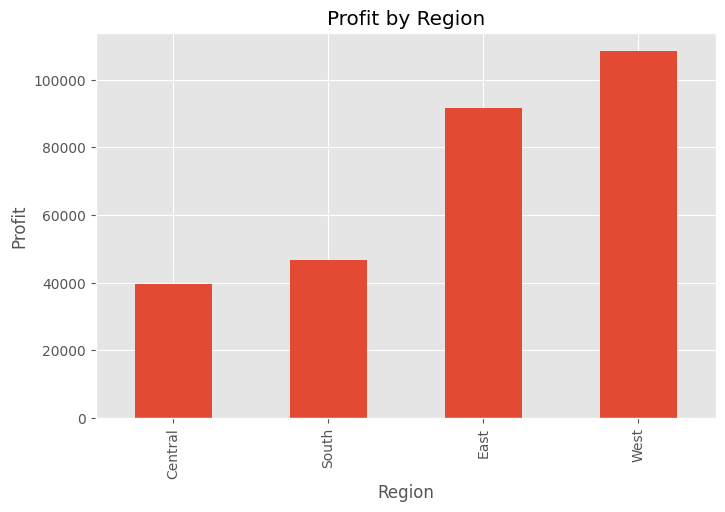

In [60]:
region['Profit'].plot(kind='bar', figsize=(8,5))
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()

In [61]:
category = df.groupby('Category').agg({
    'Sales':'sum',
    'Profit':'sum'
})

category

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


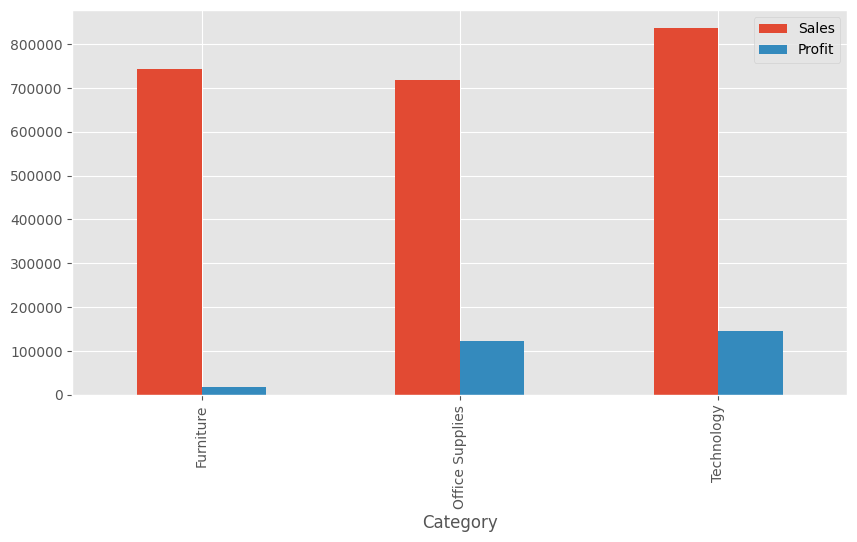

In [62]:
category.plot(kind='bar', figsize=(10,5))
plt.show()

In [65]:
subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

subcategory.head(10)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Name: Profit, dtype: float64

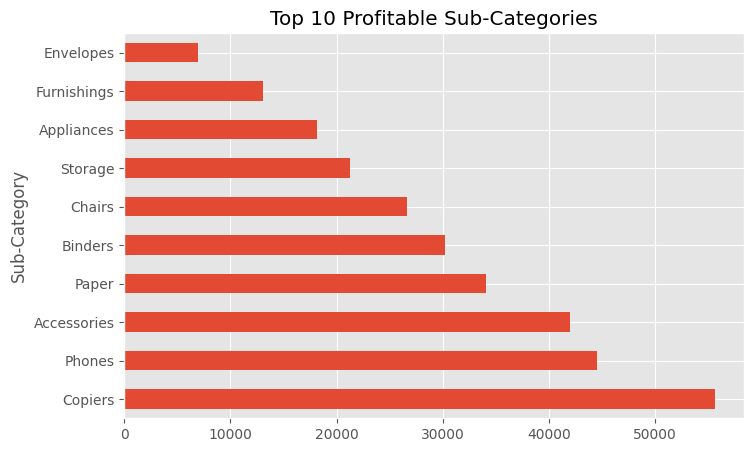

In [66]:
subcategory.head(10).plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Profitable Sub-Categories")
plt.show()

In [67]:
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values()

loss_products.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [68]:
segment = df.groupby('Segment')['Sales'].sum()

segment

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

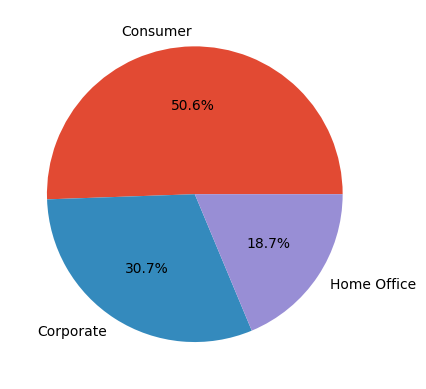

In [69]:
segment.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.show()

In [70]:
discount = df.groupby('Discount').agg({
    'Sales':'sum',
    'Profit':'sum'
})

discount

,Sales,Profit
Discount,,
0.00,1.087908e+06,320987.6032
0.10,5.436935e+04,9029.1770
0.15,2.755852e+04,1418.9915
0.20,7.645944e+05,90337.3060
0.30,1.032267e+05,-10369.2774
0.32,1.449346e+04,-2391.1377
0.40,1.164178e+05,-23057.0504
0.45,5.484974e+03,-2493.1111
0.50,5.891854e+04,-20506.4281


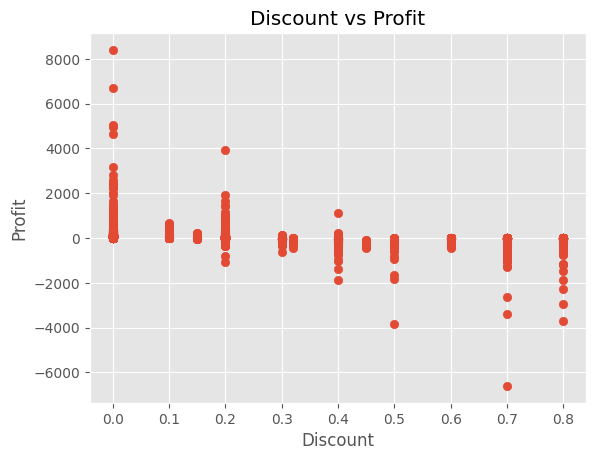

In [71]:
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

In [72]:
monthly = df.groupby('Month_Name')['Sales'].sum()

monthly

Month_Name
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

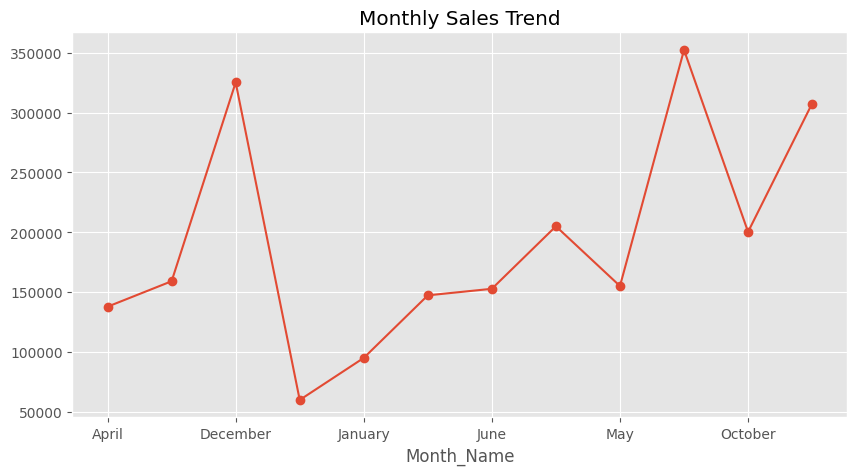

In [73]:
monthly.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

In [74]:
df['Delivery_Days'].mean()

np.float64(3.958174904942966)

In [75]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

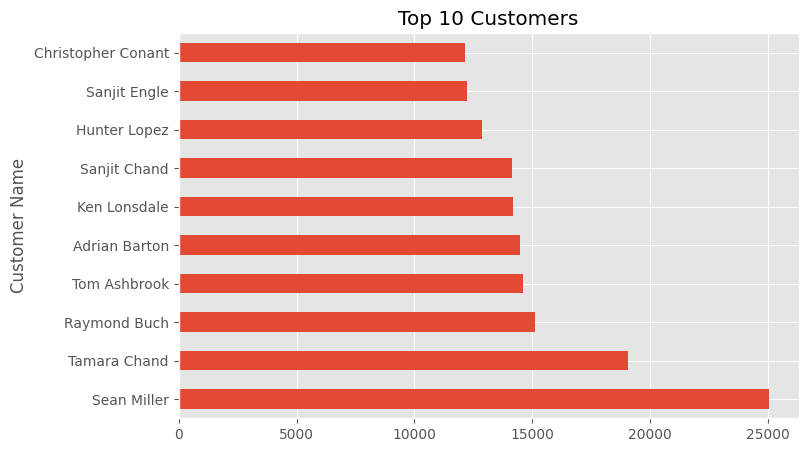

In [76]:
top_customers.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Customers")
plt.show()